In [52]:
from langgraph.graph import StateGraph , START , END
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict ,Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [43]:
load_dotenv()

True

In [44]:
# model = ChatNVIDIA(model="nvidia/nemotron-3-super-120b-a12b")
model = ChatGoogleGenerativeAI(model='gemini-3.6-flash')

In [45]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage],add_messages]

In [46]:
def Chat_node(state:ChatState):

    message = state['messages']

    response = model.invoke(message)

    return {'messages':[response]}

In [53]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('Chat_node',Chat_node)

graph.add_edge(START,'Chat_node')
graph.add_edge('Chat_node',END)

chatflow = graph.compile(checkpointer=checkpointer)

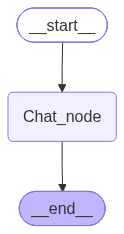

In [48]:
chatflow

In [54]:
thread_id = '1'
while True:

    user_message = input("user:")
    print('user:',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    else:
        config = {'configurable':{'thread_id':thread_id}}
        response = chatflow.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
        print('AI:',response['messages'][-1].content[0]['text'])

user: hi
AI: Hello! How can I help you today?
user: my name is dhanush
AI: Nice to meet you, Dhanush! How can I help you today?
user: add 10 to 100
AI: 100 + 10 = **110**
user: multiply by 2
AI: 110 × 2 = **220**
user: what is my name 
AI: Your name is Dhanush!
user: bye


In [55]:
chatflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='eb3210ea-add4-4c27-9ad7-7723aee9d6d1'), AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Et4FCtsFARFNMg+OD4GF+IUFkMOdrX5Kfe7zMoZD5JDOQ5fTZuEPWq0RJVqh34IOASIrva7cLajZzsN71ovWjvvguoDiEM+L2i2WIjC+iiFzGM2bHtPsryj3llhkj0z3j4kKgUZOpG8xFFA9RBEqFeGRkXdjaRjomzq8HgEToPgYX9TDs4ILYUfTi9UMvYbxd+gNMixgf+B0iF4WZ65VjS991cYrcLBXyxEvGyXiYQVKiw7iQW80zOMniK4/MbkO/CIHVdb8w379U/r/E7z6cqeZOt35S0RXdaLQs5xti4+nikyKrr1UtvCTsXiAPQyGojKihU7uNzTc2rOJA9sjgh4IrVlEdzR1YCm5t/wBHmkU7UeLtD9wEyIQc1a2X3p00Uw/7wrJsm1BjoxZB/ieNCygssBPGIjvi0HbhVF1NHuZ0d0pIJbDEET3RIcDEdAOFlgl33iaZniYFlj4Pbhu3gR/m+RTC1TogYhhSoh9F0MYsao5Z3X1Fvkk2+a/o2Ou6vei00hsN6Nm6VQbf6vT4dxf9j2qFkl/KfnRhP5LWoKW5O2MiNiYbdOedvQdZGR6SlIXoMiRdn6kEHDFWs3JN/88jjtJrhg/3GV03b7pu94FuihvpGDfAw6Wnj6EkYBc3Csq5TPLpLiT/sb9AgVGG2CEgQgqjXKUCDSb20Op8EQmz4YE3nViHeE3ewlx22yajY8jWk0CO/Kf8pl3hnmBBuxhDDPb78jTeF33N/tvG